# Q-INTERVAL-Lite+ — Mammogram Classification (Final Pipeline)

**Author:** Pasindu Pahasara · 104348348
**Project:** COS40005 Computing Technology Project A — Sprint 2 Final Model
**Architecture:** ResNet-50 with progressive unfreezing, mixed precision, cosine annealing LR, early stopping on Malignant recall, calibrated risk scoring, and Grad-CAM++ explainability.

This notebook contains the final, polished training and inference pipeline for the breast cancer mammogram classification system. It applies the full set of improvements developed during Sprint 2:

1. Reproducibility seeds across all random number sources
2. Stratified patient-level data split using a maximum-severity rule
3. Data integrity verification (multi-label patients and ID collisions)
4. Albumentations augmentation pipeline at 384×384 resolution
5. Mammo-Bench-specific normalisation (replacing ImageNet defaults)
6. CLAHE, brightness/contrast jitter, and CoarseDropout augmentations
7. Class-weighted cross-entropy loss
8. Regularised classifier head (Dropout + 256-hidden + Dropout)
9. AdamW optimizer with weight decay
10. Progressive unfreezing with discriminative learning rates
11. Mixed precision (AMP) training
12. Cosine annealing learning rate scheduler
13. Early stopping based on validation Malignant recall
14. Temperature scaling for calibrated probability outputs
15. Risk score with Low / Moderate / High bands
16. Grad-CAM++ visual explainability

## 1. Imports and reproducibility

Setting deterministic seeds across `random`, `numpy`, `torch`, `cuda`, and `cudnn` ensures that every experiment is reproducible. This is a foundation for being able to compare experimental variations meaningfully.

In [6]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds set to {SEED}. Reproducible mode: ON.")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Seeds set to 42. Reproducible mode: ON.
Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Load metadata

Mammo-Bench is an aggregate of six mammography datasets. The `metadata.csv` file contains image paths, classifications, view, laterality, density, BI-RADS, and patient identifiers. We load it and verify that the image paths resolve correctly.

In [7]:
DATA_ROOT = "."
CSV_PATH = "metadata.csv"

df = pd.read_csv(CSV_PATH)

# Verify the first image path exists
sample_path = df.iloc[0]["preprocessed_image_path"]
full_path = os.path.normpath(os.path.join(DATA_ROOT, sample_path))
print(f"Sample path: {full_path}")
print(f"Path exists: {os.path.exists(full_path)}")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Sample path: Preprocessed_Dataset\inbreast\inbreast_0.jpg
Path exists: True

Dataset shape: (19731, 25)
Columns: ['source_dataset', 'preprocessed_image_path', 'classification', 'density', 'BIRADS', 'mask_path', 'raw_image_path', 'laterality', 'view', 'source_subjectID', 'original_source_path', 'subject_age', 'abnormality', 'molecular_subtype', 'ROI_path', 'x', 'y', 'radius', 'abnormality id', 'calc type', 'calc distribution', 'subtlety', 'mass shape', 'mass margins', 'cropped_image_file_new']


## 3. Label mapping

The raw dataset contains four labels: Normal, Benign, Malignant, and Suspicious Malignant. We map "Suspicious Malignant" to the Malignant class to simplify the classification problem and avoid ambiguity. Numeric label indices are used internally (Normal=0, Benign=1, Malignant=2).

In [8]:
def map_label(label):
    if label == "Normal":
        return "Normal"
    elif label == "Benign":
        return "Benign"
    elif label in ["Malignant", "Suspicious Malignant"]:
        return "Malignant"
    else:
        raise ValueError(f"Unexpected label: {label!r}")

df["final_label"] = df["classification"].apply(map_label)

label_map = {"Normal": 0, "Benign": 1, "Malignant": 2}
reverse_map = {0: "Normal", 1: "Benign", 2: "Malignant"}
df["label_id"] = df["final_label"].map(label_map)

print("Class distribution:")
print(df["final_label"].value_counts())

Class distribution:
final_label
Malignant    8419
Benign       6069
Normal       5243
Name: count, dtype: int64


## 4. Data integrity check

Before splitting, we verify two things:

1. **How many patients have multiple distinct labels?** This tells us the rate of clinical heterogeneity (e.g., one breast normal, the other malignant).
2. **Are subject IDs globally unique?** We check whether any `source_subjectID` appears in more than one source dataset. If so, we would need to construct a composite ID to prevent unrelated patients from being treated as the same person.

In [9]:
# Check: how many subjects have multiple distinct labels?
subject_label_counts = df.groupby('source_subjectID')['final_label'].nunique()
multi_label_subjects = subject_label_counts[subject_label_counts > 1]

print(f"Total subjects:                   {len(subject_label_counts)}")
print(f"Subjects with multiple labels:    {len(multi_label_subjects)}")
print(f"Percentage with multiple labels:  {100 * len(multi_label_subjects) / len(subject_label_counts):.2f}%")

# Check: does any source_subjectID appear in more than one source_dataset?
collisions = df.groupby('source_subjectID')['source_dataset'].nunique()
n_colliding = (collisions > 1).sum()
print(f"\nCross-dataset ID collisions:      {n_colliding}")
print(f"Percentage colliding:             {100 * n_colliding / len(collisions):.2f}%")

Total subjects:                   5860
Subjects with multiple labels:    535
Percentage with multiple labels:  9.13%

Cross-dataset ID collisions:      0
Percentage colliding:             0.00%


## 5. Build final dataframe

We construct full image paths, verify they exist on disk, and keep only the columns we need for training.

In [10]:
df["full_image_path"] = df["preprocessed_image_path"].apply(
    lambda x: os.path.join(DATA_ROOT, x)
)

missing = df[~df["full_image_path"].apply(os.path.exists)]
print(f"Missing image files: {len(missing)}")

columns_needed = [
    "full_image_path",
    "final_label",
    "label_id",
    "source_subjectID",
    "density",
    "BIRADS",
]
df = df[columns_needed].copy()
print(f"Final dataframe shape: {df.shape}")
df.head()

Missing image files: 0
Final dataframe shape: (19731, 6)


,full_image_path,final_label,label_id,source_subjectID,density,BIRADS
0,.\Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,0,22678622,D,1.0
1,.\Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,1,22678646,D,3.0
2,.\Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,0,22678670,D,1.0
3,.\Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,1,22678694,D,3.0
4,.\Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,2,22614074,B,5.0


## 6. Stratified group split (70 / 15 / 15)

The split is patient-aware (no patient appears in more than one fold) **and** class-stratified (each fold has roughly the same class proportions). We collapse each patient to a single label using a **maximum-severity rule**: a patient is assigned the Malignant label for stratification if any of their images is Malignant. This prevents malignant cases from being unevenly distributed across folds.

Note that this rule only affects how we *stratify*; the actual training labels remain per-image.

In [11]:
from sklearn.model_selection import train_test_split

subject_col = 'source_subjectID'

# Each subject collapsed to their maximum-severity label (Malignant > Benign > Normal)
subject_label_df = (
    df.groupby(subject_col)['label_id']
      .max()
      .reset_index()
      .rename(columns={'label_id': 'subject_label'})
)
print("Subject-level class distribution (max-severity rule):")
print(subject_label_df['subject_label']
        .map({0: 'Normal', 1: 'Benign', 2: 'Malignant'})
        .value_counts())

subjects = subject_label_df[subject_col].values
subject_labels = subject_label_df['subject_label'].values

# 70 / 15 / 15 stratified split
train_subjects, temp_subjects, _, temp_subj_labels = train_test_split(
    subjects, subject_labels,
    test_size=0.30, random_state=SEED,
    stratify=subject_labels,
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.50, random_state=SEED,
    stratify=temp_subj_labels,
)

train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df   = df[df[subject_col].isin(val_subjects)].copy()
test_df  = df[df[subject_col].isin(test_subjects)].copy()

print(f"\nTrain subjects: {len(train_subjects)}, images: {len(train_df)}")
print(f"Val   subjects: {len(val_subjects)}, images: {len(val_df)}")
print(f"Test  subjects: {len(test_subjects)}, images: {len(test_df)}")

# Verify zero overlap and class balance
train_set, val_set, test_set = set(train_subjects), set(val_subjects), set(test_subjects)
print(f"\nOverlap check (must be 0/0/0):")
print(f"Train ∩ Val:  {len(train_set & val_set)}")
print(f"Train ∩ Test: {len(train_set & test_set)}")
print(f"Val   ∩ Test: {len(val_set & test_set)}")

print(f"\nTrain class distribution:\n{train_df['final_label'].value_counts()}")
print(f"\nVal   class distribution:\n{val_df['final_label'].value_counts()}")
print(f"\nTest  class distribution:\n{test_df['final_label'].value_counts()}")

Subject-level class distribution (max-severity rule):
subject_label
Malignant    2679
Benign       2095
Normal       1086
Name: count, dtype: int64

Train subjects: 4102, images: 13780
Val   subjects: 879, images: 2935
Test  subjects: 879, images: 3016

Overlap check (must be 0/0/0):
Train ∩ Val:  0
Train ∩ Test: 0
Val   ∩ Test: 0

Train class distribution:
final_label
Malignant    5879
Benign       4255
Normal       3646
Name: count, dtype: int64

Val   class distribution:
final_label
Malignant    1258
Benign        903
Normal        774
Name: count, dtype: int64

Test  class distribution:
final_label
Malignant    1282
Benign        911
Normal        823
Name: count, dtype: int64


## 7. Compute Mammo-Bench mean and standard deviation

The original ImageNet normalisation values `[0.485, 0.456, 0.406]` are calibrated for natural colour photographs. Mammograms are grayscale images converted to 3-channel RGB, so all three channels are identical. We compute the actual mean and standard deviation on the training set so the model receives correctly-normalised inputs.

This is a one-time computation (~2–3 minutes); the values are then used in the augmentation pipeline.

In [12]:
from tqdm import tqdm

sums = np.zeros(3, dtype=np.float64)
sums_sq = np.zeros(3, dtype=np.float64)
count = 0

print(f"Computing mean/std over {len(train_df)} training images...")
for path in tqdm(train_df['full_image_path'].values, desc="Stats"):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    sums += img.mean(axis=(0, 1))
    sums_sq += (img ** 2).mean(axis=(0, 1))
    count += 1

MEAN = (sums / count).tolist()
STD = np.sqrt(sums_sq / count - (sums / count) ** 2).tolist()

print(f"\nMammo-Bench train MEAN: {MEAN}")
print(f"Mammo-Bench train STD : {STD}")

Computing mean/std over 13780 training images...


Stats: 100%|██████████| 13780/13780 [18:35<00:00, 12.36it/s] 


Mammo-Bench train MEAN: [0.20708730262325717, 0.20708730262325717, 0.20708730262325717]
Mammo-Bench train STD : [0.275669406583642, 0.275669406583642, 0.275669406583642]


## 8. Augmentation pipeline (Albumentations)

We use the Albumentations library for a richer augmentation pipeline than torchvision provides. Augmentations applied during training:

- `Resize(384, 384)` — increased from 224 to better capture small lesions and microcalcifications
- `HorizontalFlip` and `VerticalFlip` — anatomically valid for mammograms
- `ShiftScaleRotate` — small geometric variations
- `RandomBrightnessContrast` — accounts for screening machine variation
- `CLAHE` (Contrast Limited Adaptive Histogram Equalization) — enhances local contrast in tissue
- `CoarseDropout` — random occlusion forces robust features
- `Normalize` — using the Mammo-Bench-specific stats computed above

Validation and test transforms only resize and normalise; no randomness.

In [13]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

INPUT_SIZE = 384

train_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.CoarseDropout(max_holes=2, max_height=24, max_width=24, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print("Augmentation pipelines defined.")

Augmentation pipelines defined.


## 9. PyTorch Dataset class

The dataset reads images using OpenCV (which Albumentations expects) and applies the appropriate transform pipeline.

In [14]:
from torch.utils.data import Dataset

class MammoBenchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = cv2.imread(row['full_image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, row['label_id']

## 10. DataLoaders

A reduced batch size of 12 is used because 384×384 images consume roughly three times the GPU memory of 224×224 inputs. `pin_memory=True` enables asynchronous GPU transfer. `num_workers=0` is required on Windows + Jupyter due to a known multiprocessing compatibility issue.

In [15]:
from torch.utils.data import DataLoader

train_dataset = MammoBenchDataset(train_df, transform=train_transform)
val_dataset   = MammoBenchDataset(val_df,   transform=val_test_transform)
test_dataset  = MammoBenchDataset(test_df,  transform=val_test_transform)

BATCH_SIZE = 12

g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
    generator=g, worker_init_fn=seed_worker,
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Image batch shape:  {images.shape}")
print(f"Label batch shape:  {labels.shape}")
print(f"Pixel value range:  [{images.min().item():.3f}, {images.max().item():.3f}]")

Image batch shape:  torch.Size([12, 3, 384, 384])
Label batch shape:  torch.Size([12])
Pixel value range:  [-0.751, 2.876]


## 11. Model architecture

We use ResNet-50 with ImageNet pre-trained weights as the backbone, with a regularised classifier head:

```
Dropout(0.3) → Linear(2048, 256) → ReLU → Dropout(0.3) → Linear(256, 3)
```

The backbone is frozen initially; we use **progressive unfreezing** during training (see Section 13).

**Class weights** are computed from the training labels using the `'balanced'` strategy. **AdamW** is used (rather than Adam) for proper decoupled weight decay.

In [16]:
from sklearn.utils.class_weight import compute_class_weight
from torchvision import models

# ----- Class weights -----
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label_id'].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights [Normal, Benign, Malignant]: {class_weights.tolist()}")

# ----- Build model -----
def build_model():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    num_features = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, 3),
    )
    return m

model = build_model().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ----- Helpers for progressive unfreezing -----
def set_requires_grad(module, requires_grad):
    for p in module.parameters():
        p.requires_grad = requires_grad

def build_optimizer(model, head_lr=1e-3, layer4_lr=None, layer3_lr=None,
                    weight_decay=1e-4):
    groups = []
    head_params = [p for p in model.fc.parameters() if p.requires_grad]
    if head_params:
        groups.append({'params': head_params, 'lr': head_lr})
    if layer4_lr is not None:
        l4 = [p for p in model.layer4.parameters() if p.requires_grad]
        if l4:
            groups.append({'params': l4, 'lr': layer4_lr})
    if layer3_lr is not None:
        l3 = [p for p in model.layer3.parameters() if p.requires_grad]
        if l3:
            groups.append({'params': l3, 'lr': layer3_lr})
    return torch.optim.AdamW(groups, weight_decay=weight_decay)

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"\nInitial trainable parameters: {count_trainable(model):,}")
print("\nClassifier head:")
print(model.fc)

Class weights [Normal, Benign, Malignant]: [1.2598280906677246, 1.0795142650604248, 0.7813119888305664]

Initial trainable parameters: 525,315

Classifier head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=3, bias=True)
)


## 12. Training and validation functions

`train_epoch` uses **mixed precision** (`torch.amp.autocast` + `GradScaler`) which roughly doubles training throughput on the RTX 4050 by using fp16 where safe. `validate_one_epoch` returns per-class recall in addition to the loss and accuracy, so we can track the **Malignant recall** which is the most clinically important metric in screening.

In [17]:
from tqdm import tqdm
from torch.amp import autocast, GradScaler
from sklearn.metrics import recall_score

def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item())
    return running_loss / total, correct / total


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    epoch_loss = running_loss / len(all_labels)
    epoch_acc  = (all_preds == all_labels).mean()
    per_class_recall = recall_score(all_labels, all_preds,
                                     average=None, labels=[0, 1, 2],
                                     zero_division=0)
    return epoch_loss, epoch_acc, per_class_recall[2], per_class_recall

## 13. Progressive unfreezing training

A three-phase training schedule with discriminative learning rates:

| Phase | Trainable layers | Epochs | Learning rates |
|---|---|---|---|
| 1 | Head only | 3 | head: 1e-3 |
| 2 | Head + layer4 | 5 | head: 1e-3, layer4: 1e-4 |
| 3 | Head + layer4 + layer3 | 12 | head: 1e-3, layer4: 1e-4, layer3: 1e-5 |

Each phase uses a **cosine annealing learning rate scheduler** (decays smoothly to `eta_min=1e-6`). **Early stopping** on validation Malignant recall (patience=8, reset per phase) protects against overfitting while giving each phase a fair chance to find a better optimum. The best model checkpoint (by Malignant recall) is saved as `best_resnet50_final.pth`.

In [18]:
from torch.optim.lr_scheduler import CosineAnnealingLR

PATIENCE = 8
train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_mal_recalls = []
best_malignant_recall = 0.0
patience_counter = 0
scaler = GradScaler('cuda')

CHECKPOINT_PATH = "best_resnet50_final.pth"


def run_phase(name, num_epochs, model, optimizer, criterion, device, scaler):
    global best_malignant_recall, patience_counter
    patience_counter = 0  # reset per-phase so each phase gets a fair chance
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    print(f"\n{'='*70}\n{name}\nTrainable params: {count_trainable(model):,}\n{'='*70}")
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        vl_loss, vl_acc, mal_recall, all_recalls = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()
        train_losses.append(tr_loss); val_losses.append(vl_loss)
        train_accs.append(tr_acc);    val_accs.append(vl_acc)
        val_mal_recalls.append(mal_recall)
        cur_lr = scheduler.get_last_lr()[0]
        print(f"[{name} {epoch+1:>2}/{num_epochs}] "
              f"train {tr_loss:.4f}/{tr_acc:.3f} | "
              f"val {vl_loss:.4f}/{vl_acc:.3f} | "
              f"recall N {all_recalls[0]:.3f}  B {all_recalls[1]:.3f}  M {all_recalls[2]:.3f} | "
              f"lr {cur_lr:.2e}")
        if mal_recall > best_malignant_recall:
            best_malignant_recall = mal_recall
            patience_counter = 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"   New best Malignant recall: {mal_recall:.4f}. Saved.")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   Early stopping ({PATIENCE} epochs without Malignant-recall improvement).")
                return True
    return False


# ----- Phase 1: head only -----
set_requires_grad(model, False)
set_requires_grad(model.fc, True)
optimizer = build_optimizer(model, head_lr=1e-3)
stopped = run_phase("Phase 1: head only", 3, model, optimizer, criterion, device, scaler)

# ----- Phase 2: + layer4 -----
if not stopped:
    set_requires_grad(model.layer4, True)
    optimizer = build_optimizer(model, head_lr=1e-3, layer4_lr=1e-4)
    stopped = run_phase("Phase 2: + layer4", 5, model, optimizer, criterion, device, scaler)

# ----- Phase 3: + layer3 -----
if not stopped:
    set_requires_grad(model.layer3, True)
    optimizer = build_optimizer(model, head_lr=1e-3, layer4_lr=1e-4, layer3_lr=1e-5)
    stopped = run_phase("Phase 3: + layer3", 32, model, optimizer, criterion, device, scaler)

print(f"\nBest Malignant recall across all phases: {best_malignant_recall:.4f}")


Phase 1: head only
Trainable params: 525,315


[Phase 1: head only  1/3] train 0.9735/0.510 | val 0.8360/0.600 | recall N 0.849  B 0.498  M 0.520 | lr 7.50e-04
   New best Malignant recall: 0.5199. Saved.


[Phase 1: head only  2/3] train 0.8907/0.548 | val 0.7848/0.614 | recall N 0.674  B 0.522  M 0.643 | lr 2.51e-04
   New best Malignant recall: 0.6431. Saved.


[Phase 1: head only  3/3] train 0.8625/0.565 | val 0.7809/0.618 | recall N 0.800  B 0.573  M 0.538 | lr 1.00e-06

Phase 2: + layer4
Trainable params: 15,490,051


[Phase 2: + layer4  1/5] train 0.7836/0.602 | val 0.7334/0.652 | recall N 0.755  B 0.647  M 0.593 | lr 9.05e-04


...

[Phase 3: + layer3  8/32] train 0.6063/0.702 | val 0.6514/0.716 | recall N 0.854  B 0.661  M 0.669 | lr 8.54e-04


[Phase 3: + layer3  9/32] train 0.5975/0.712 | val 0.6799/0.682 | recall N 0.930  B 0.619  M 0.576 | lr 8.17e-04


[Phase 3: + layer3 10/32] train 0.5846/0.714 | val 0.6396/0.722 | recall N 0.864  B 0.621  M 0.707 | lr 7.78e-04


[Phase 3: + layer3 11/32] train 0.5759/0.724 | val 0.6781/0.675 | recall N 0.904  B 0.654  M 0.549 | lr 7.36e-04


[Phase 3: + layer3 12/32] train 0.5690/0.720 | val 0.6675/0.709 | recall N 0.886  B 0.638  M 0.651 | lr 6.92e-04
   Early stopping (8 epochs without Malignant-recall improvement).

Best Malignant recall across all phases: 0.7289


## 14. Training curves

Plot training and validation loss / accuracy / Malignant recall over all epochs across the three phases.

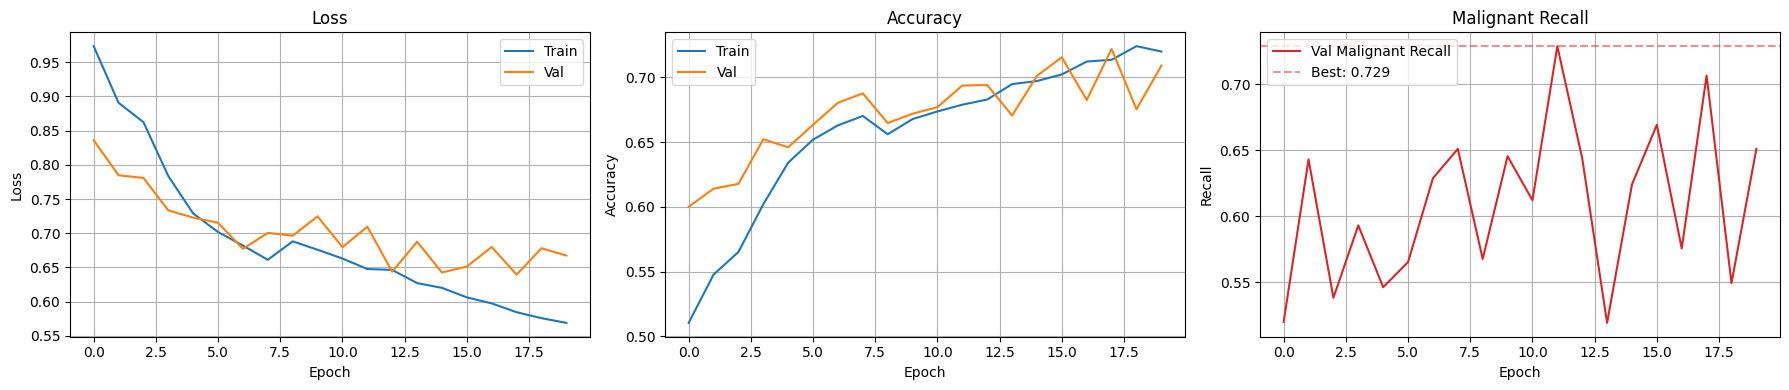

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(val_mal_recalls, label='Val Malignant Recall', color='tab:red')
axes[2].axhline(y=best_malignant_recall, color='tab:red', linestyle='--', alpha=0.5, label=f'Best: {best_malignant_recall:.3f}')
axes[2].set_title('Malignant Recall')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Recall'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout(); plt.show()

## 15. Test set evaluation

We load the best saved checkpoint and evaluate on the held-out test set. Metrics reported:

- Test accuracy
- Per-class precision, recall, F1-score
- Macro and weighted averages
- Confusion matrix (as percentages)

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

# Load best model
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

# Predict on test set
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device); labels = labels.to(device)
        with autocast(device_type='cuda'):
            logits = model(images)
        probs = torch.softmax(logits, dim=1)
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.concatenate(all_probs)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Test Accuracy:    {acc:.4f}")
print(f"Weighted Prec :    {prec:.4f}")
print(f"Weighted Recall:   {rec:.4f}")
print(f"Weighted F1:       {f1:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Benign', 'Malignant'], zero_division=0))

Test Accuracy:    0.6989
Weighted Prec :    0.6985
Weighted Recall:   0.6989
Weighted F1:       0.6986
Macro F1:          0.6981

Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.79      0.80       823
      Benign       0.57      0.56      0.57       911
   Malignant       0.71      0.74      0.73      1282

    accuracy                           0.70      3016
   macro avg       0.70      0.70      0.70      3016
weighted avg       0.70      0.70      0.70      3016



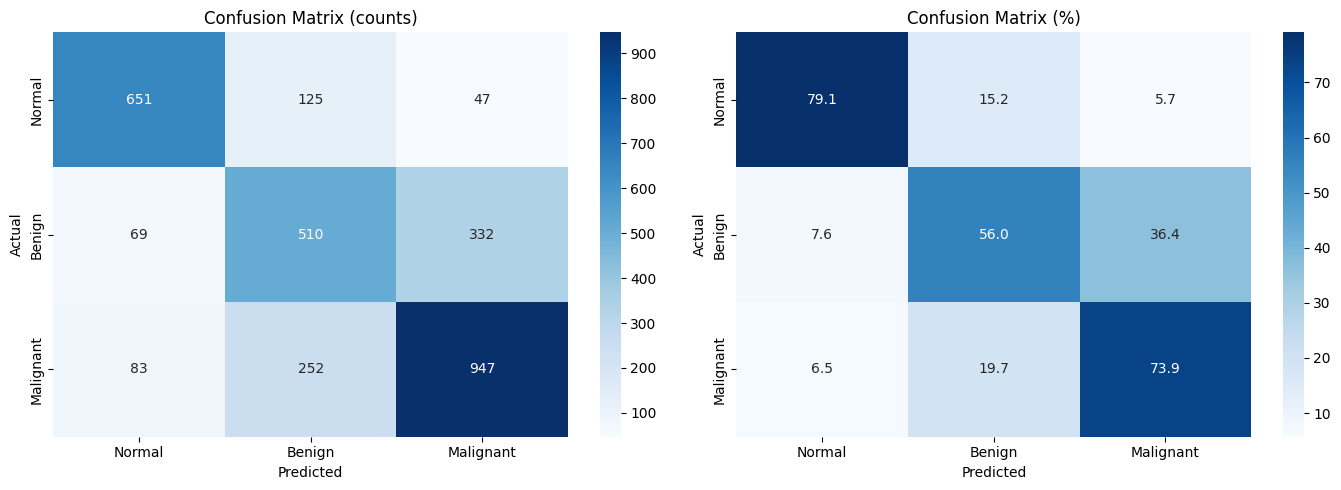

In [21]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Benign', 'Malignant'],
            yticklabels=['Normal', 'Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Normal', 'Benign', 'Malignant'],
            yticklabels=['Normal', 'Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout(); plt.show()

## 16. ROC-AUC and clinical metrics

For a medical screening application, **sensitivity (recall) for the Malignant class** and **specificity** are more clinically meaningful than overall accuracy. We compute one-vs-rest ROC-AUC for each class.

In [22]:
# One-vs-rest ROC-AUC
y_true_onehot = np.eye(3)[y_true]
auc_per_class = roc_auc_score(y_true_onehot, y_probs, average=None, multi_class='ovr')
auc_macro = roc_auc_score(y_true_onehot, y_probs, average='macro', multi_class='ovr')

print(f"ROC-AUC per class:")
for i, name in enumerate(['Normal', 'Benign', 'Malignant']):
    print(f"  {name:<10s}: {auc_per_class[i]:.4f}")
print(f"\nMacro ROC-AUC:  {auc_macro:.4f}")

# Clinical sensitivity/specificity — Malignant vs. non-Malignant
malignant_true = (y_true == 2).astype(int)
malignant_pred = (y_pred == 2).astype(int)
TP = ((malignant_pred == 1) & (malignant_true == 1)).sum()
TN = ((malignant_pred == 0) & (malignant_true == 0)).sum()
FP = ((malignant_pred == 1) & (malignant_true == 0)).sum()
FN = ((malignant_pred == 0) & (malignant_true == 1)).sum()

sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
print(f"\nMalignant (binary) sensitivity: {sensitivity:.4f}")
print(f"Malignant (binary) specificity:  {specificity:.4f}")

ROC-AUC per class:
  Normal    : 0.9557
  Benign    : 0.7881
  Malignant : 0.8339

Macro ROC-AUC:  0.8592

Malignant (binary) sensitivity: 0.7387
Malignant (binary) specificity:  0.7814


## 17. Calibration via temperature scaling

Modern deep classifiers tend to be over-confident: a model predicting `P(Malignant) = 0.9` is typically wrong more than 10% of the time. We apply **temperature scaling** (Guo et al. 2017): a single scalar temperature `T > 0` is fit on the validation set to divide the logits before softmax. This reduces over-confidence while preserving the predicted class.

We measure calibration with:
- **Expected Calibration Error (ECE)** — the average gap between confidence and observed accuracy across confidence bins.
- **Brier score** — mean squared error between predicted probability and true label.

In [23]:
# Get validation logits and labels
val_logits, val_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        with autocast(device_type='cuda'):
            logits = model(images)
        val_logits.append(logits.float().cpu())
        val_labels.append(labels)
val_logits = torch.cat(val_logits)
val_labels = torch.cat(val_labels)

# Temperature scaling: optimise T to minimise NLL on validation set
temperature = nn.Parameter(torch.ones(1) * 1.0)
optimizer_T = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

def temp_loss():
    optimizer_T.zero_grad()
    loss = nn.CrossEntropyLoss()(val_logits / temperature, val_labels)
    loss.backward()
    return loss

optimizer_T.step(temp_loss)
T_optimal = temperature.item()
print(f"Optimal temperature T = {T_optimal:.4f}")
print(f"(T > 1 → original was over-confident; T < 1 → under-confident)")

Optimal temperature T = 1.1416
(T > 1 → original was over-confident; T < 1 → under-confident)


In [24]:
# Compute ECE and Brier score before and after calibration
def expected_calibration_error(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if in_bin.sum() > 0:
            avg_conf = confidences[in_bin].mean()
            avg_acc = accuracies[in_bin].mean()
            ece += in_bin.sum() / len(probs) * abs(avg_conf - avg_acc)
    return ece

def brier_score(probs, labels):
    onehot = np.eye(probs.shape[1])[labels]
    return np.mean(np.sum((probs - onehot) ** 2, axis=1))

# Test set logits — apply temperature
test_logits = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        with autocast(device_type='cuda'):
            logits = model(images)
        test_logits.append(logits.float().cpu())
test_logits = torch.cat(test_logits)

probs_uncal = torch.softmax(test_logits, dim=1).numpy()
probs_cal   = torch.softmax(test_logits / T_optimal, dim=1).numpy()

ece_uncal = expected_calibration_error(probs_uncal, y_true)
ece_cal   = expected_calibration_error(probs_cal,   y_true)
brier_uncal = brier_score(probs_uncal, y_true)
brier_cal   = brier_score(probs_cal,   y_true)

print(f"Before calibration:  ECE = {ece_uncal:.4f}, Brier = {brier_uncal:.4f}")
print(f"After  calibration:  ECE = {ece_cal:.4f}, Brier = {brier_cal:.4f}")
print(f"\nECE reduction: {(ece_uncal - ece_cal) / ece_uncal * 100:.1f}%")

Before calibration:  ECE = 0.0399, Brier = 0.4070
After  calibration:  ECE = 0.0293, Brier = 0.4050

ECE reduction: 26.6%


## 18. Reliability diagram

Visualises calibration: a perfectly calibrated model lies on the diagonal. The diagram is plotted before and after temperature scaling.

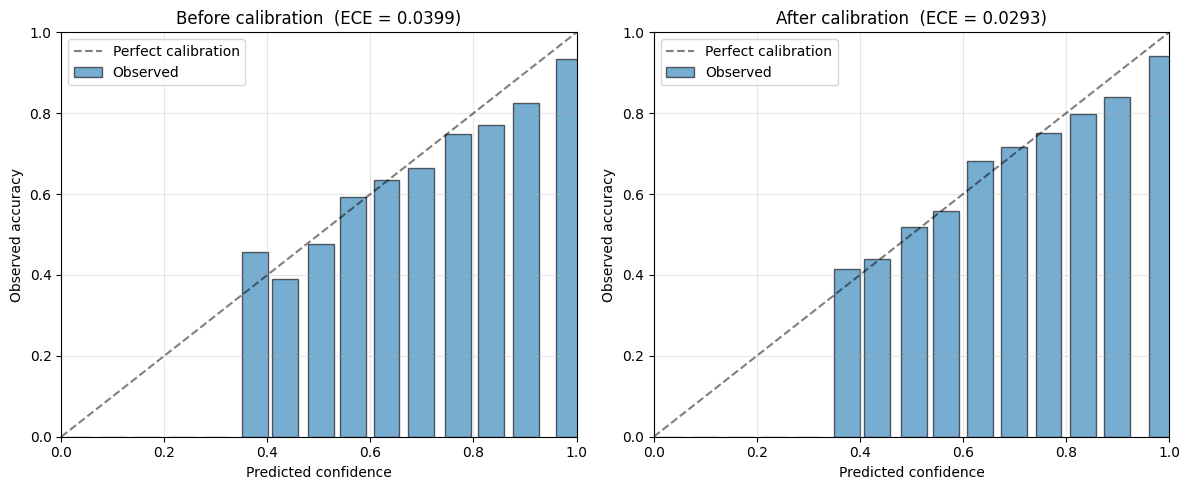

In [25]:
def reliability_data(probs, labels, n_bins=15):
    confs = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    accs = (preds == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    bin_confs, bin_accs, bin_counts = [], [], []
    for i in range(n_bins):
        m = (confs > bins[i]) & (confs <= bins[i+1])
        if m.sum() > 0:
            bin_confs.append(confs[m].mean())
            bin_accs.append(accs[m].mean())
            bin_counts.append(m.sum())
        else:
            bin_confs.append((bins[i]+bins[i+1])/2)
            bin_accs.append(0)
            bin_counts.append(0)
    return np.array(bin_confs), np.array(bin_accs), np.array(bin_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs, title, ece in [
    (axes[0], probs_uncal, 'Before calibration', ece_uncal),
    (axes[1], probs_cal,   'After calibration',  ece_cal),
]:
    bc, ba, bn = reliability_data(probs, y_true)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.bar(bc, ba, width=0.05, alpha=0.6, edgecolor='black', label='Observed')
    ax.set_title(f'{title}  (ECE = {ece:.4f})')
    ax.set_xlabel('Predicted confidence'); ax.set_ylabel('Observed accuracy')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 19. Calibrated risk score with bands

The client requested a probabilistic risk score rather than a discrete classification. We use the **calibrated `P(Malignant)`** directly (mapped to 0–100%) and assign a clinical risk band:

| Band | Calibrated risk | Recommendation |
|---|---|---|
| Low | < 30% | Routine screening |
| Moderate | 30 – 60% | Specialist review recommended |
| High | > 60% | Urgent specialist review required |

This replaces the heuristic formula `Risk = P_Malignant * 100 + P_Benign * 30` from the Sprint 1 inference cell, which was not a calibrated probability.

In [26]:
def risk_score_from_probs(probs):
    """probs is a 1D array of [P_Normal, P_Benign, P_Malignant]"""
    p_malignant = float(probs[2])
    risk_pct = p_malignant * 100
    if risk_pct < 30:
        band, message = "Low", "Routine screening recommended."
    elif risk_pct < 60:
        band, message = "Moderate", "Specialist review recommended."
    else:
        band, message = "High", "Urgent specialist review required."
    return risk_pct, band, message

## 20. Grad-CAM++ visual explainability

Grad-CAM++ (Chattopadhyay et al. 2018) generates class-discriminative visual explanations by computing weighted gradients of the target class score with respect to the final convolutional feature maps. We apply it to ResNet-50's `layer4` and overlay the resulting heatmap onto the original mammogram.

This visualisation shows which regions of the image most influenced the model's prediction. It is the input to the front-end heatmap display.

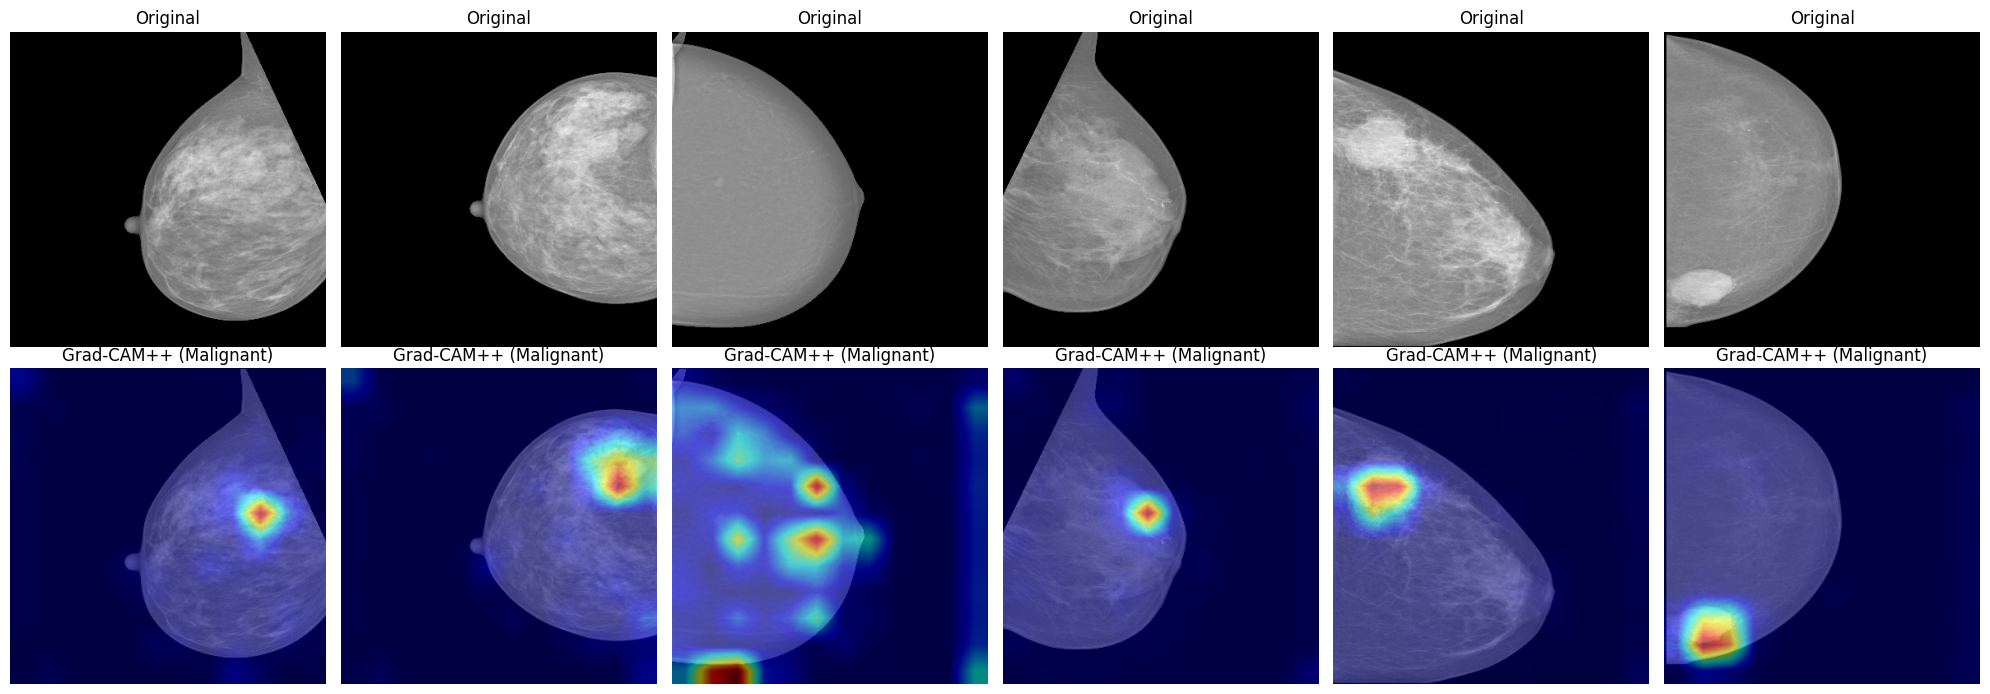

In [27]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.layer4[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)


def make_gradcam_overlay(image_path, target_class=2, alpha=0.5):
    """Generate a Grad-CAM++ overlay for a single image. target_class=2 is Malignant."""
    image_rgb = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)
    image_rgb = cv2.resize(image_rgb, (INPUT_SIZE, INPUT_SIZE))
    image_norm = image_rgb.astype(np.float32) / 255.0

    transformed = val_test_transform(image=image_rgb)['image'].unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=transformed, targets=targets)[0]
    overlay = show_cam_on_image(image_norm, grayscale_cam, use_rgb=True, image_weight=1-alpha)
    return image_rgb, overlay


# Sample a few malignant test cases
malignant_test_paths = test_df[test_df['label_id'] == 2]['full_image_path'].head(6).tolist()

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for col, path in enumerate(malignant_test_paths):
    img, overlay = make_gradcam_overlay(path, target_class=2)
    axes[0, col].imshow(img); axes[0, col].set_title('Original'); axes[0, col].axis('off')
    axes[1, col].imshow(overlay); axes[1, col].set_title('Grad-CAM++ (Malignant)'); axes[1, col].axis('off')
plt.tight_layout(); plt.show()

## 21. Single-image inference function

Combines everything: loads an image, runs it through the model with the calibrated temperature, returns the predicted class, calibrated probabilities, risk score with band, and a Grad-CAM++ overlay. This is the function the FastAPI backend will call.

In [28]:
def predict_with_explanation(image_path, target_class_for_cam=2):
    """
    Returns:
      predicted_class (str), probabilities (dict),
      risk_pct (float), band (str), message (str),
      gradcam_overlay (np.ndarray)
    """
    # Read + transform
    img_rgb = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    transformed = val_test_transform(image=img_rgb)['image'].unsqueeze(0).to(device)

    # Calibrated prediction
    model.eval()
    with torch.no_grad():
        with autocast(device_type='cuda'):
            logits = model(transformed)
        probs = torch.softmax(logits.float() / T_optimal, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = reverse_map[pred_idx]
    risk_pct, band, message = risk_score_from_probs(probs)

    probabilities = {
        'Normal':    float(probs[0]),
        'Benign':    float(probs[1]),
        'Malignant': float(probs[2]),
    }

    # Grad-CAM++
    _, overlay = make_gradcam_overlay(image_path, target_class=target_class_for_cam)

    return pred_class, probabilities, risk_pct, band, message, overlay


# Demo on one test image
sample_path = test_df['full_image_path'].iloc[0]
pred_class, probs, risk_pct, band, message, overlay = predict_with_explanation(sample_path)

print(f"Predicted class:    {pred_class}")
print(f"Probabilities:")
for k, v in probs.items():
    print(f"  {k:<10s}: {v*100:.2f}%")
print(f"\nRisk score:         {risk_pct:.2f}%")
print(f"Risk band:          {band}")
print(f"Recommendation:     {message}")

Predicted class:    Benign
Probabilities:
  Normal    : 29.36%
  Benign    : 61.70%
  Malignant : 8.94%

Risk score:         8.94%
Risk band:          Low
Recommendation:     Routine screening recommended.


## 22. Save final artefacts

We save the model weights, the optimal temperature, the normalisation statistics, and the input size in a single bundle. This makes the FastAPI backend deterministic — it loads exactly the same configuration that produced the test results.

In [29]:
import joblib

artefacts = {
    'model_state_dict': model.state_dict(),
    'temperature': T_optimal,
    'mean': MEAN,
    'std':  STD,
    'input_size': INPUT_SIZE,
    'class_names': ['Normal', 'Benign', 'Malignant'],
    'risk_bands': {'Low': '<30%', 'Moderate': '30-60%', 'High': '>60%'},
    'test_metrics': {
        'accuracy': float(acc),
        'macro_f1': float(macro_f1),
        'malignant_recall': float(recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)[2]),
        'macro_auc': float(auc_macro),
        'sensitivity_malignant': float(sensitivity),
        'specificity_malignant': float(specificity),
        'ece_uncalibrated': float(ece_uncal),
        'ece_calibrated':   float(ece_cal),
    }
}

torch.save(artefacts, "final_model_bundle.pth")
print("Saved: final_model_bundle.pth")
print("\nFinal test metrics:")
for k, v in artefacts['test_metrics'].items():
    print(f"  {k:<25s}: {v:.4f}")

Saved: final_model_bundle.pth

Final test metrics:
  accuracy                 : 0.6989
  macro_f1                 : 0.6981
  malignant_recall         : 0.7387
  macro_auc                : 0.8592
  sensitivity_malignant    : 0.7387
  specificity_malignant    : 0.7814
  ece_uncalibrated         : 0.0399
  ece_calibrated           : 0.0293
